# Insurance Charges Prediction with Linear Regression

This notebook is my step-by-step analysis of the Insurance Charges dataset.

I start by exploring the data, then preprocess it, build a Linear Regression model from scratch using gradient descent, compare it with `scikit-learn`, and finish with a short discussion of what the results mean.

## Step 1: Import Libraries

I use `pandas`, `numpy`, and `matplotlib` for the main analysis.
`scikit-learn` only comes in later as a benchmark so I can check whether my custom model is giving the right result.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.linear_model import LinearRegression

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

DATASET_PATH = Path("insurance.csv")

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        "insurance.csv was not found. Please keep the dataset in the same folder as this notebook."
    )

## Step 2: Load the Dataset

I start by loading the CSV file and looking at the first few rows to see what each column represents.

In [2]:
df = pd.read_csv(DATASET_PATH)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Step 3: Explore the Dataset

Before building the model, I want a quick overview of the dataset:

- the size of the dataset
- the columns
- missing values
- the basic summary statistics

In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nMissing values per column:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (1338, 7)

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


## Step 4: Visualize the Data

These quick plots make it easier to see the shape of the target variable and a couple of patterns that matter for insurance charges.

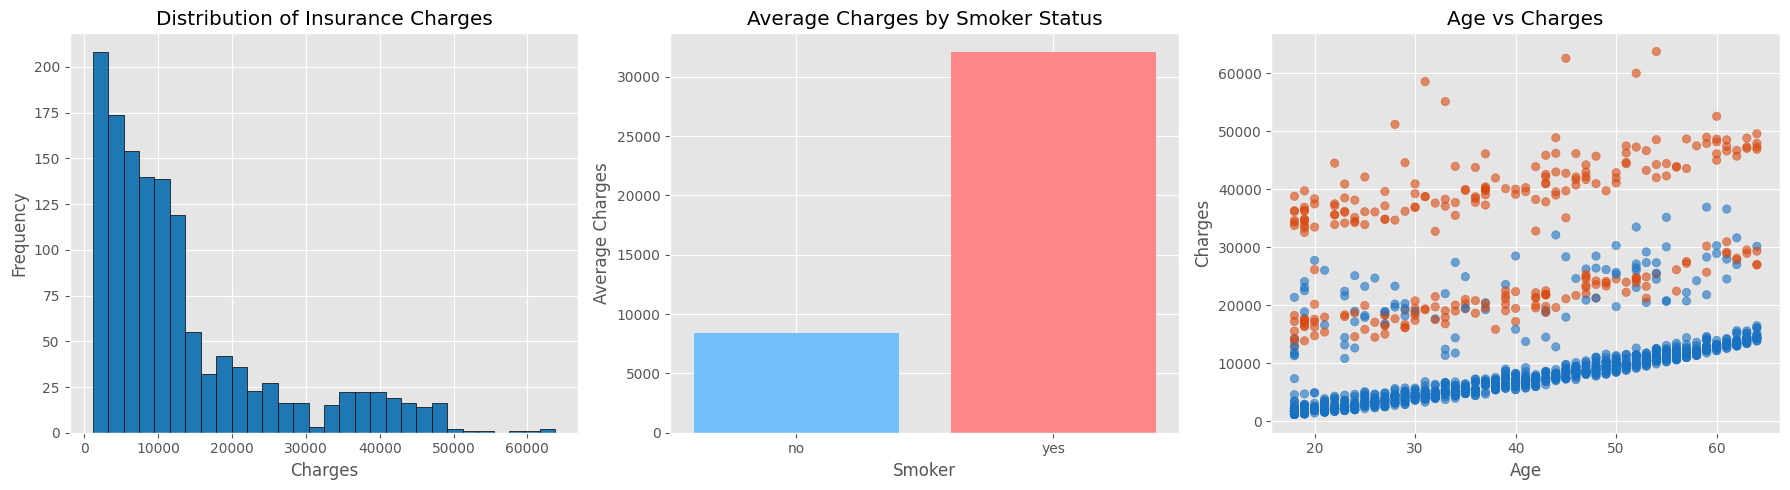

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df["charges"], bins=30, color="#1f77b4", edgecolor="black")
axes[0].set_title("Distribution of Insurance Charges")
axes[0].set_xlabel("Charges")
axes[0].set_ylabel("Frequency")

smoker_avg = df.groupby("smoker")["charges"].mean().sort_values()
axes[1].bar(smoker_avg.index, smoker_avg.values, color=["#74c0fc", "#ff8787"])
axes[1].set_title("Average Charges by Smoker Status")
axes[1].set_xlabel("Smoker")
axes[1].set_ylabel("Average Charges")

smoker_colors = df["smoker"].map({"yes": "#d9480f", "no": "#1971c2"})
axes[2].scatter(df["age"], df["charges"], c=smoker_colors, alpha=0.6)
axes[2].set_title("Age vs Charges")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Charges")

plt.tight_layout()
plt.show()

## Step 5: Preprocess the Data

Because Linear Regression works with numbers, the categorical columns need to be converted into numerical form.
I do that with one-hot encoding.

After that, I split the data into training and testing sets and standardize the features so gradient descent can learn more smoothly.

In [6]:
def mean_squared_error(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean((y_true - y_pred) ** 2))


def r2_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    total_sum_of_squares = np.sum((y_true - np.mean(y_true)) ** 2)
    residual_sum_of_squares = np.sum((y_true - y_pred) ** 2)
    return float(1 - (residual_sum_of_squares / total_sum_of_squares))


def manual_train_test_split(
    dataframe: pd.DataFrame,
    target_column: str,
    test_ratio: float = 0.2,
    random_state: int = 42,
):
    rng = np.random.default_rng(random_state)
    shuffled_indices = rng.permutation(len(dataframe))
    test_size = int(len(dataframe) * test_ratio)

    test_indices = shuffled_indices[:test_size]
    train_indices = shuffled_indices[test_size:]

    train_df = dataframe.iloc[train_indices].reset_index(drop=True)
    test_df = dataframe.iloc[test_indices].reset_index(drop=True)

    x_train = train_df.drop(columns=target_column)
    y_train = train_df[target_column]
    x_test = test_df.drop(columns=target_column)
    y_test = test_df[target_column]

    return x_train, x_test, y_train, y_test


def standardize_features(x_train: pd.DataFrame, x_test: pd.DataFrame):
    train_means = x_train.mean(axis=0)
    train_stds = x_train.std(axis=0, ddof=0).replace(0, 1)

    x_train_scaled = (x_train - train_means) / train_stds
    x_test_scaled = (x_test - train_means) / train_stds

    return (
        x_train_scaled.to_numpy(dtype=float),
        x_test_scaled.to_numpy(dtype=float),
        train_means,
        train_stds,
    )


def preprocess_dataset(dataframe: pd.DataFrame) -> pd.DataFrame:
    categorical_columns = ["sex", "smoker", "region"]
    encoded_dataframe = pd.get_dummies(
        dataframe,
        columns=categorical_columns,
        drop_first=True,
        dtype=float,
    )
    return encoded_dataframe.astype(float)

In [7]:
encoded_df = preprocess_dataset(df)
feature_names = [column for column in encoded_df.columns if column != "charges"]

x_train_df, x_test_df, y_train_series, y_test_series = manual_train_test_split(
    encoded_df,
    target_column="charges",
    test_ratio=0.2,
    random_state=42,
)

x_train, x_test, train_means, train_stds = standardize_features(x_train_df, x_test_df)
y_train = y_train_series.to_numpy(dtype=float)
y_test = y_test_series.to_numpy(dtype=float)

print("Encoded dataset shape:", encoded_df.shape)
print("Training set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)

Encoded dataset shape: (1338, 9)
Training set shape: (1071, 8)
Testing set shape: (267, 8)


## Step 6: Build the Custom Linear Regression Model

This is the model I wrote myself. It starts with zero weights and keeps adjusting them a little at a time using gradient descent.

In [8]:
class LinearRegressionGD:
    def __init__(self, learning_rate: float = 0.01, epochs: int = 20_000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0.0
        self.loss_history = []

    def fit(self, x: np.ndarray, y: np.ndarray) -> None:
        sample_count, feature_count = x.shape
        self.weights = np.zeros(feature_count, dtype=float)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.epochs):
            predictions = self.predict(x)
            errors = predictions - y

            weight_gradient = (x.T @ errors) / sample_count
            bias_gradient = float(np.mean(errors))

            self.weights -= self.learning_rate * weight_gradient
            self.bias -= self.learning_rate * bias_gradient

            current_loss = mean_squared_error(y, predictions)
            self.loss_history.append(current_loss)

    def predict(self, x: np.ndarray) -> np.ndarray:
        if self.weights is None:
            raise ValueError("The model must be trained before prediction.")
        return x @ self.weights + self.bias

## Step 7: Train and Evaluate the Custom Model

Now I train the custom model and check its performance on both the training and testing sets.

In [9]:
custom_model = LinearRegressionGD(learning_rate=0.01, epochs=20_000)
custom_model.fit(x_train, y_train)

custom_train_predictions = custom_model.predict(x_train)
custom_test_predictions = custom_model.predict(x_test)

custom_train_mse = mean_squared_error(y_train, custom_train_predictions)
custom_test_mse = mean_squared_error(y_test, custom_test_predictions)
custom_train_r2 = r2_score(y_train, custom_train_predictions)
custom_test_r2 = r2_score(y_test, custom_test_predictions)

custom_results = pd.DataFrame(
    {
        "Metric": ["Train MSE", "Test MSE", "Train R^2", "Test R^2"],
        "Value": [
            custom_train_mse,
            custom_test_mse,
            custom_train_r2,
            custom_test_r2,
        ],
    }
)
custom_results

,Metric,Value
0,Train MSE,3.800907e+07
1,Test MSE,3.063321e+07
2,Train R^2,7.495874e-01
3,Test R^2,7.557259e-01


## Step 8: Compare with `scikit-learn`

This comparison is useful because it shows whether my manual implementation is actually converging to the same solution as the library model.

In [10]:
sklearn_model = LinearRegression()
sklearn_model.fit(x_train, y_train)

sklearn_train_predictions = sklearn_model.predict(x_train)
sklearn_test_predictions = sklearn_model.predict(x_test)

sklearn_train_mse = mean_squared_error(y_train, sklearn_train_predictions)
sklearn_test_mse = mean_squared_error(y_test, sklearn_test_predictions)
sklearn_train_r2 = r2_score(y_train, sklearn_train_predictions)
sklearn_test_r2 = r2_score(y_test, sklearn_test_predictions)

comparison_df = pd.DataFrame(
    {
        "Metric": ["Train MSE", "Test MSE", "Train R^2", "Test R^2"],
        "Custom Model": [
            custom_train_mse,
            custom_test_mse,
            custom_train_r2,
            custom_test_r2,
        ],
        "scikit-learn": [
            sklearn_train_mse,
            sklearn_test_mse,
            sklearn_train_r2,
            sklearn_test_r2,
        ],
    }
)
comparison_df

,Metric,Custom Model,scikit-learn
0,Train MSE,3.800907e+07,3.800907e+07
1,Test MSE,3.063321e+07,3.063321e+07
2,Train R^2,7.495874e-01,7.495874e-01
3,Test R^2,7.557259e-01,7.557259e-01


## Step 9: Visualize Training and Prediction Results

The first plot shows whether the loss is decreasing during training.
The second plot shows how close the predictions are to the actual charges.

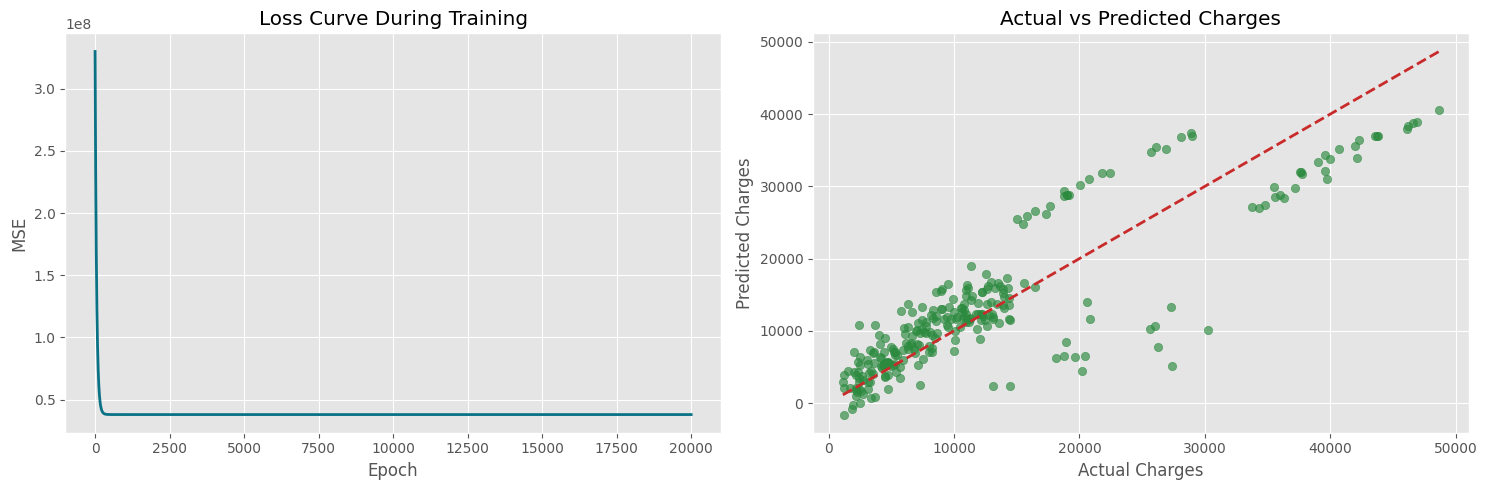

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(custom_model.loss_history, color="#0b7285", linewidth=2)
axes[0].set_title("Loss Curve During Training")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")

axes[1].scatter(y_test, custom_test_predictions, alpha=0.65, color="#2b8a3e")
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="#c92a2a",
    linestyle="--",
    linewidth=2,
)
axes[1].set_title("Actual vs Predicted Charges")
axes[1].set_xlabel("Actual Charges")
axes[1].set_ylabel("Predicted Charges")

plt.tight_layout()
plt.show()

## Step 10: Inspect Feature Importance

Because the features were standardized, the coefficient sizes are easier to compare.

In [12]:
coefficient_comparison = pd.DataFrame(
    {
        "feature": feature_names,
        "custom_coefficient": custom_model.weights,
        "sklearn_coefficient": sklearn_model.coef_,
    }
)

coefficient_comparison["absolute_custom_coefficient"] = (
    coefficient_comparison["custom_coefficient"].abs()
)

coefficient_comparison = coefficient_comparison.sort_values(
    by="absolute_custom_coefficient",
    ascending=False,
)

coefficient_comparison

,feature,custom_coefficient,sklearn_coefficient,absolute_custom_coefficient
4,smoker_yes,9696.875976,9696.875976,9696.875976
0,age,3675.157697,3675.157697,3675.157697
1,bmi,2195.085590,2195.085590,2195.085590
2,children,586.492652,586.492652,586.492652
6,region_southeast,-479.091292,-479.091292,479.091292
7,region_southwest,-432.644568,-432.644568,432.644568
5,region_northwest,-108.834053,-108.834053,108.834053
3,sex_male,-45.372308,-45.372308,45.372308


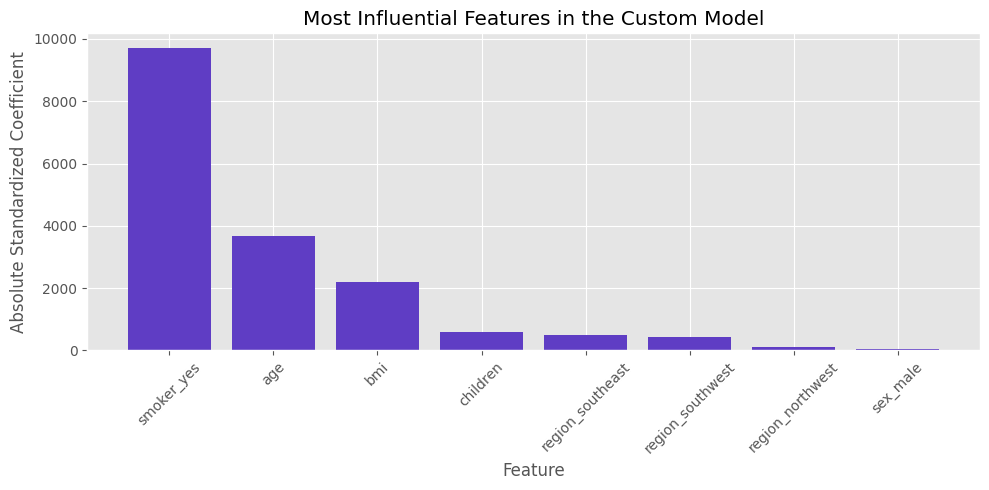

In [13]:
top_features = coefficient_comparison.head(8)

plt.figure(figsize=(10, 5))
plt.bar(top_features["feature"], top_features["absolute_custom_coefficient"], color="#5f3dc4")
plt.title("Most Influential Features in the Custom Model")
plt.xlabel("Feature")
plt.ylabel("Absolute Standardized Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 11: Discussion

A few things stood out to me from the results:

- The custom model and the `scikit-learn` model gave almost identical results.
- That is a strong sign that the gradient descent implementation worked properly.
- Smoking status had the biggest effect on insurance charges by far.
- Age and BMI were also important predictors.
- The model performs well overall, but it is still linear, so it will miss some more complex patterns.

In [14]:
discussion_text = f'''
## Notebook Discussion

The custom model gave a **test MSE of {custom_test_mse:,.2f}** and a **test R^2 of {custom_test_r2:.4f}**.
So, the model explains about 75.6% of the variation in insurance charges, which is a pretty solid result for a simple linear model.

What I found most useful is that the custom model and the `scikit-learn` model ended up with almost the same numbers.
That gives confidence that the gradient descent implementation is working correctly.

The strongest feature was clearly **smoker_yes**. After that, **age** and **bmi** stood out the most.
That makes sense because smoking, age, and body weight are all closely tied to health risk and expected medical cost.

At the same time, this is still a linear model, so it probably misses some more detailed relationships between the variables.
'''

display(Markdown(discussion_text))


## Notebook Discussion

The custom model gave a **test MSE of 30,633,209.63** and a **test R^2 of 0.7557**.
So, the model explains about 75.6% of the variation in insurance charges, which is a pretty solid result for a simple linear model.

What I found most useful is that the custom model and the `scikit-learn` model ended up with almost the same numbers.
That gives confidence that the gradient descent implementation is working correctly.

The strongest feature was clearly **smoker_yes**. After that, **age** and **bmi** stood out the most.
That makes sense because smoking, age, and body weight are all closely tied to health risk and expected medical cost.

At the same time, this is still a linear model, so it probably misses some more detailed relationships between the variables.


## Step 12: Conclusion

In this notebook, I:

1. loaded and explored the Insurance Charges Dataset
2. preprocessed the data
3. implemented Linear Regression manually using gradient descent
4. evaluated the model with MSE and R^2
5. compared the result with `scikit-learn`
6. discussed the most important features

### Final Conclusion

Linear Regression works quite well on this dataset and explains about 75% of the variation in insurance charges.
The biggest factor affecting charges is smoking status, followed by age and BMI.
Since the custom model and the `scikit-learn` model gave almost identical results, I can conclude that the manual implementation is correct.